In [239]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.inspection import permutation_importance

In [240]:
df_all=pd.read_csv("./../data/ssm_all_features_extended.csv")

In [241]:
df_all

,0,1,2,3,4,5,6,7,8,9,...,state_input_distance,long_term_state_drift,state_similarity,state_input_similarity,long_term_state_similarity,mean_squared_change_short,mean_squared_change_long,conv_id,turn_id,y
0,-0.004938,0.010028,-0.009252,0.005573,0.004999,0.004853,-0.015082,-0.023915,0.014907,0.005539,...,1.060708,0.000000,0.000000,0.064875,1.000000,0.000235,0.000000,0.0,0.0,0
1,-0.005842,0.028222,-0.015452,-0.032046,0.014550,0.003275,-0.012755,-0.021501,0.033707,0.023255,...,1.122548,0.285567,0.808949,-0.028589,0.808949,0.000106,0.000106,0.0,1.0,1
2,0.002231,0.032334,-0.024924,-0.034721,0.016211,-0.005692,-0.002074,-0.026771,0.027421,0.023131,...,1.142455,0.377847,0.882606,-0.047110,0.684473,0.000076,0.000186,0.0,2.0,1
3,-0.015485,-0.014725,0.005911,0.019545,0.010477,-0.001654,-0.009771,-0.001021,0.006958,-0.011655,...,1.077727,0.000000,0.000000,-0.014866,1.000000,0.000195,0.000000,1.0,0.0,1
4,0.021614,0.011441,-0.005190,-0.016628,-0.003228,-0.013043,-0.000234,0.005934,0.004089,0.014867,...,1.103862,0.000000,0.000000,-0.017649,1.000000,0.000264,0.000000,2.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3250,0.028141,0.024459,-0.010783,-0.028157,-0.004694,-0.009067,0.001867,0.006221,0.029151,0.002131,...,1.140951,0.247956,0.888274,-0.024465,0.888274,0.000080,0.000080,1105.0,1.0,0
3251,0.021432,0.030566,-0.024104,-0.016266,0.008490,0.000462,0.018579,-0.030009,0.000419,0.006191,...,1.126272,0.358986,0.780052,-0.023789,0.752965,0.000150,0.000168,1105.0,2.0,0
3252,0.016158,0.024588,-0.012411,-0.021500,0.015316,0.004914,0.020081,-0.034528,0.009645,0.010855,...,1.122902,0.380092,0.937502,-0.030448,0.716930,0.000039,0.000188,1105.0,3.0,0
3253,0.017627,0.023378,-0.015379,-0.022957,0.023361,0.008762,0.024364,-0.027640,-0.001722,-0.000399,...,1.129853,0.386390,0.932483,-0.046727,0.707347,0.000041,0.000194,1105.0,4.0,0


In [242]:
df_all.head()

,0,1,2,3,4,5,6,7,8,9,...,state_input_distance,long_term_state_drift,state_similarity,state_input_similarity,long_term_state_similarity,mean_squared_change_short,mean_squared_change_long,conv_id,turn_id,y
0,-0.004938,0.010028,-0.009252,0.005573,0.004999,0.004853,-0.015082,-0.023915,0.014907,0.005539,...,1.060708,0.000000,0.000000,0.064875,1.000000,0.000235,0.000000,0.0,0.0,0
1,-0.005842,0.028222,-0.015452,-0.032046,0.014550,0.003275,-0.012755,-0.021501,0.033707,0.023255,...,1.122548,0.285567,0.808949,-0.028589,0.808949,0.000106,0.000106,0.0,1.0,1
2,0.002231,0.032334,-0.024924,-0.034721,0.016211,-0.005692,-0.002074,-0.026771,0.027421,0.023131,...,1.142455,0.377847,0.882606,-0.047110,0.684473,0.000076,0.000186,0.0,2.0,1
3,-0.015485,-0.014725,0.005911,0.019545,0.010477,-0.001654,-0.009771,-0.001021,0.006958,-0.011655,...,1.077727,0.000000,0.000000,-0.014866,1.000000,0.000195,0.000000,1.0,0.0,1
4,0.021614,0.011441,-0.005190,-0.016628,-0.003228,-0.013043,-0.000234,0.005934,0.004089,0.014867,...,1.103862,0.000000,0.000000,-0.017649,1.000000,0.000264,0.000000,2.0,0.0,1


In [243]:
vector_list= list(str(col) for col in range(768+768))
vector_list.append("conv_id")
vector_list.append("turn_id")
features_list = list(set(df_all.columns.tolist()).difference(set(vector_list)))

In [244]:
df_vectors = df_all[vector_list]

In [245]:
df = df_all[features_list]

In [246]:
df["label"]=df["y"]
df.drop(columns=["y"], inplace=True)

C:\Users\Karim Mahmoud\AppData\Local\Temp\ipykernel_14216\3066773331.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"]=df["y"]
C:\Users\Karim Mahmoud\AppData\Local\Temp\ipykernel_14216\3066773331.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["y"], inplace=True)


In [247]:
df 

,mean_squared_change_long,long_term_state_drift,state_input_distance,state_input_similarity,state_similarity,state_drift,mean_squared_change_short,long_term_state_similarity,label
0,0.000000,0.000000,1.060708,0.064875,0.000000,0.424472,0.000235,1.000000,0
1,0.000106,0.285567,1.122548,-0.028589,0.808949,0.285567,0.000106,0.808949,1
2,0.000186,0.377847,1.142455,-0.047110,0.882606,0.240984,0.000076,0.684473,1
3,0.000000,0.000000,1.077727,-0.014866,0.000000,0.387274,0.000195,1.000000,1
4,0.000000,0.000000,1.103862,-0.017649,0.000000,0.450135,0.000264,1.000000,1
...,...,...,...,...,...,...,...,...,...
3250,0.000080,0.247956,1.140951,-0.024465,0.888274,0.247956,0.000080,0.888274,0
3251,0.000168,0.358986,1.126272,-0.023789,0.780052,0.339587,0.000150,0.752965,0
3252,0.000188,0.380092,1.122902,-0.030448,0.937502,0.173085,0.000039,0.716930,0
3253,0.000194,0.386390,1.129853,-0.046727,0.932483,0.176844,0.000041,0.707347,0


In [248]:
feature_names=df.columns.tolist()
unique_labels = df["label"].unique()

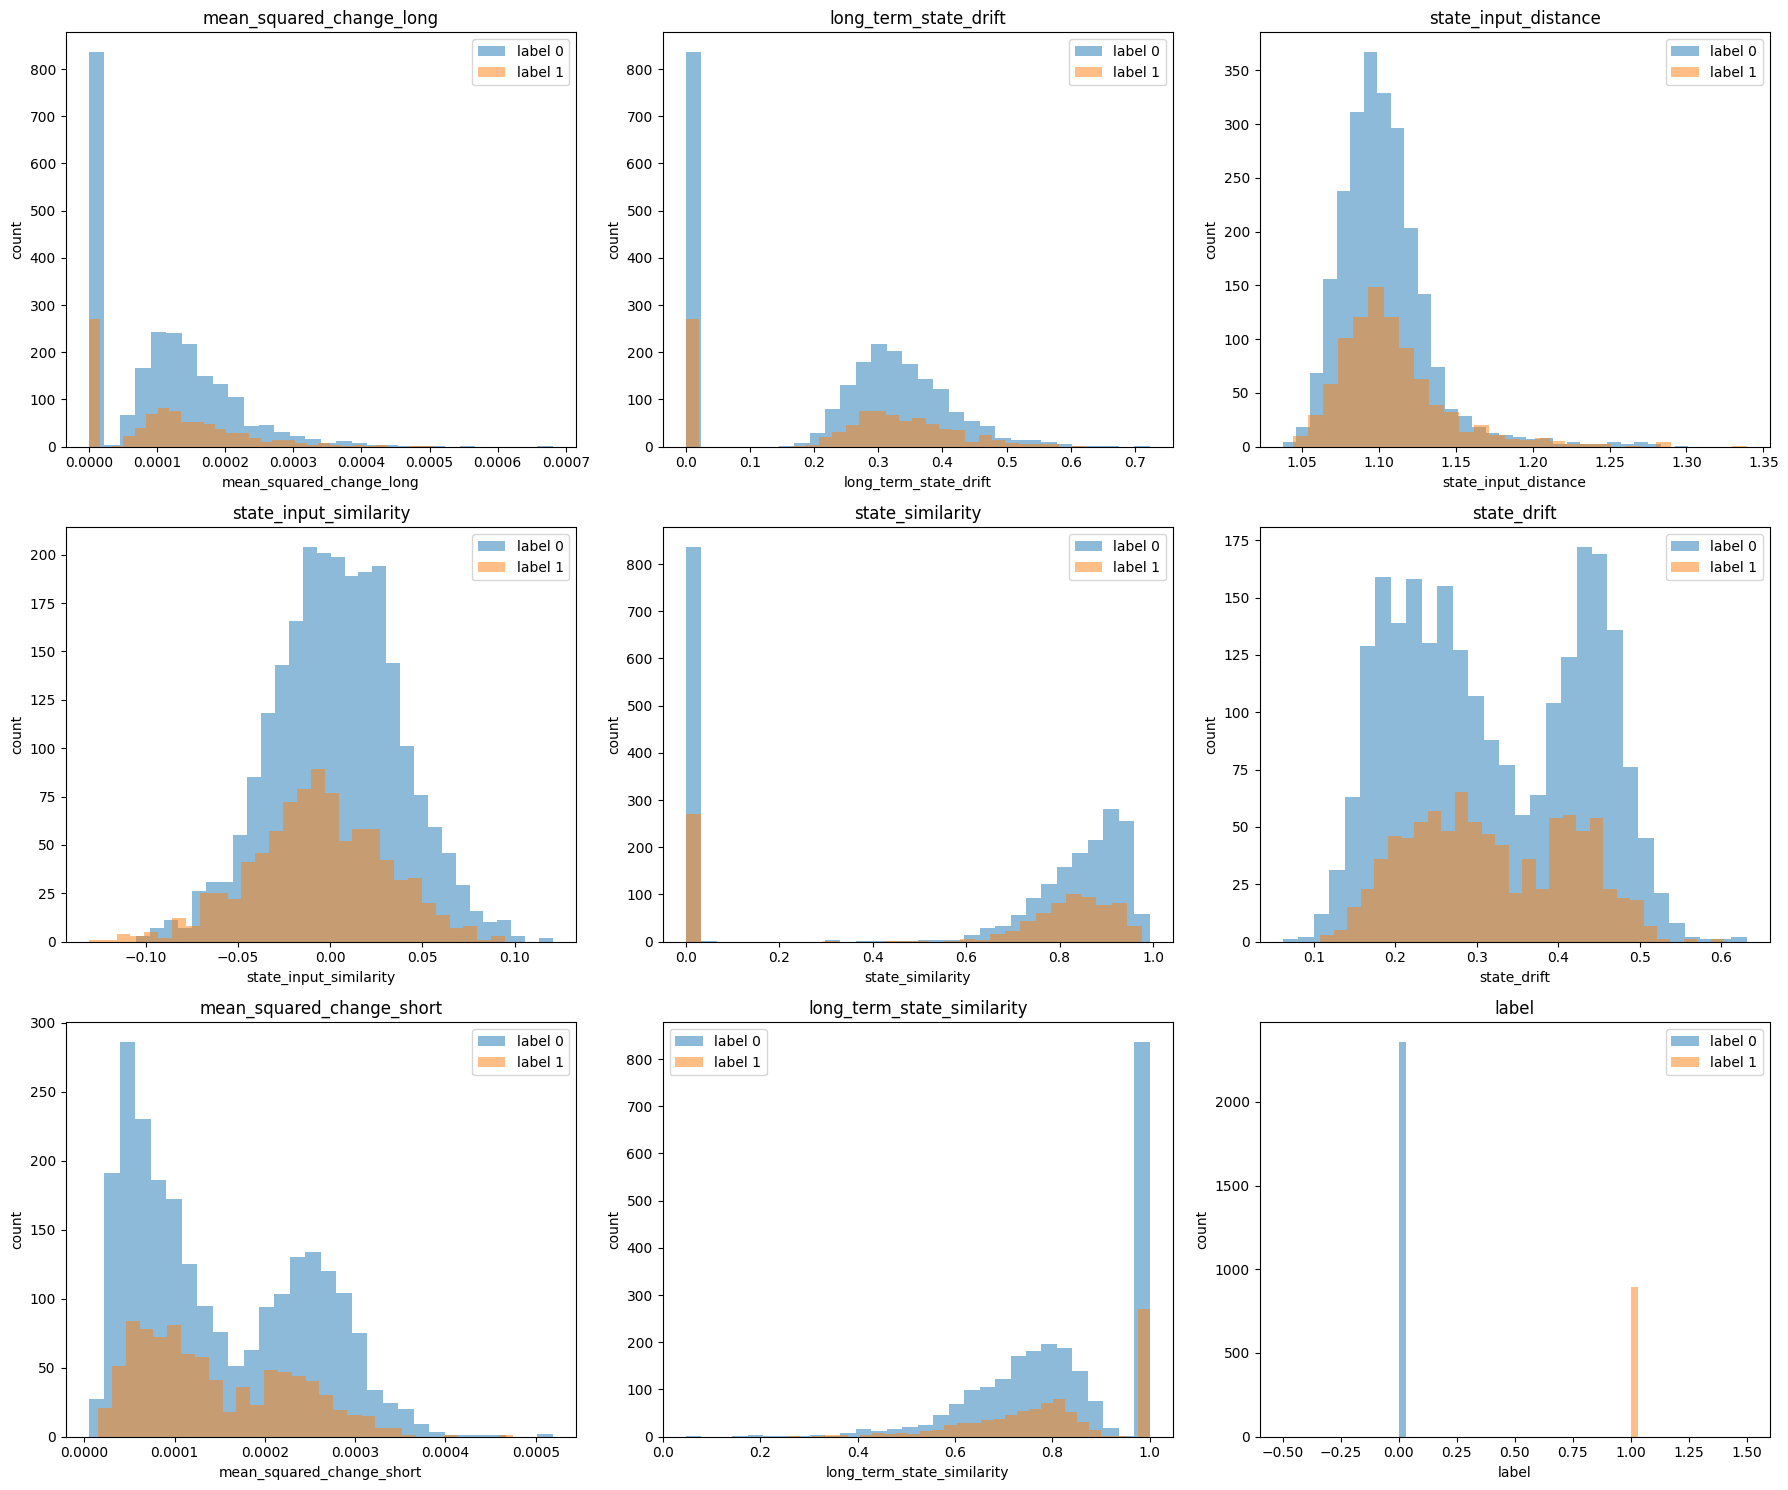

In [249]:
n_cols = 3
n_rows = int(np.ceil(len(feature_names) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(feature_names):
    ax = axes[i]

    for lbl in unique_labels:
        subset = df[df["label"] == lbl][feature]
        ax.hist(subset, bins=30, alpha=0.5, label=f"label {lbl}")

    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("count")
    ax.legend()

# remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [250]:
feature_names.pop()

'label'

In [251]:
feature_names

['mean_squared_change_long',
 'long_term_state_drift',
 'state_input_distance',
 'state_input_similarity',
 'state_similarity',
 'state_drift',
 'mean_squared_change_short',
 'long_term_state_similarity']

In [252]:
all_features = {}

for f in feature_names:
    orig = df[f].copy()
    all_features[f"{f}_orig"] = orig

    x = orig.copy()

    if x.min() <= 0:
        x = x - x.min() + 1e-6

    all_features[f"{f}_log"] = np.log(x)
    all_features[f"{f}_sqrt"] = np.sqrt(x)
    all_features[f"{f}_boxcox"], _ = stats.boxcox(x)

In [253]:
df_trans = pd.DataFrame(all_features)
df_trans["label"] = df["label"]

In [254]:
df_trans.head()

,mean_squared_change_long_orig,mean_squared_change_long_log,mean_squared_change_long_sqrt,mean_squared_change_long_boxcox,long_term_state_drift_orig,long_term_state_drift_log,long_term_state_drift_sqrt,long_term_state_drift_boxcox,state_input_distance_orig,state_input_distance_log,...,state_drift_boxcox,mean_squared_change_short_orig,mean_squared_change_short_log,mean_squared_change_short_sqrt,mean_squared_change_short_boxcox,long_term_state_similarity_orig,long_term_state_similarity_log,long_term_state_similarity_sqrt,long_term_state_similarity_boxcox,label
0,0.000000,-13.815511,0.001000,-3.332817,0.000000,-13.815511,0.001000,-5.589465,1.060708,0.058937,...,-0.677197,0.000235,-8.357607,0.015317,-3.173172,1.000000,0.000000e+00,1.000000,0.000000e+00,0
1,0.000106,-9.140976,0.010353,-3.161692,0.285567,-1.253276,0.534385,-1.136285,1.122548,0.115601,...,-0.894268,0.000106,-9.150349,0.010304,-3.237943,0.808949,-2.120188e-01,0.899416,-1.732962e-01,1
2,0.000186,-8.584956,0.013671,-3.120927,0.377847,-0.973263,0.614694,-0.901685,1.142455,0.133179,...,-0.973178,0.000076,-9.489843,0.008696,-3.261488,0.684473,-3.791064e-01,0.827329,-2.670334e-01,1
3,0.000000,-13.815511,0.001000,-3.332817,0.000000,-13.815511,0.001000,-5.589465,1.077727,0.074854,...,-0.731892,0.000195,-8.541038,0.013975,-3.189492,1.000000,1.192093e-07,1.000000,1.192093e-07,1
4,0.000000,-13.815511,0.001000,-3.332817,0.000000,-13.815511,0.001000,-5.589465,1.103862,0.098815,...,-0.640652,0.000264,-8.240206,0.016243,-3.162268,1.000000,0.000000e+00,1.000000,0.000000e+00,1


In [255]:
df_trans.columns.tolist()

['mean_squared_change_long_orig',
 'mean_squared_change_long_log',
 'mean_squared_change_long_sqrt',
 'mean_squared_change_long_boxcox',
 'long_term_state_drift_orig',
 'long_term_state_drift_log',
 'long_term_state_drift_sqrt',
 'long_term_state_drift_boxcox',
 'state_input_distance_orig',
 'state_input_distance_log',
 'state_input_distance_sqrt',
 'state_input_distance_boxcox',
 'state_input_similarity_orig',
 'state_input_similarity_log',
 'state_input_similarity_sqrt',
 'state_input_similarity_boxcox',
 'state_similarity_orig',
 'state_similarity_log',
 'state_similarity_sqrt',
 'state_similarity_boxcox',
 'state_drift_orig',
 'state_drift_log',
 'state_drift_sqrt',
 'state_drift_boxcox',
 'mean_squared_change_short_orig',
 'mean_squared_change_short_log',
 'mean_squared_change_short_sqrt',
 'mean_squared_change_short_boxcox',
 'long_term_state_similarity_orig',
 'long_term_state_similarity_log',
 'long_term_state_similarity_sqrt',
 'long_term_state_similarity_boxcox',
 'label']

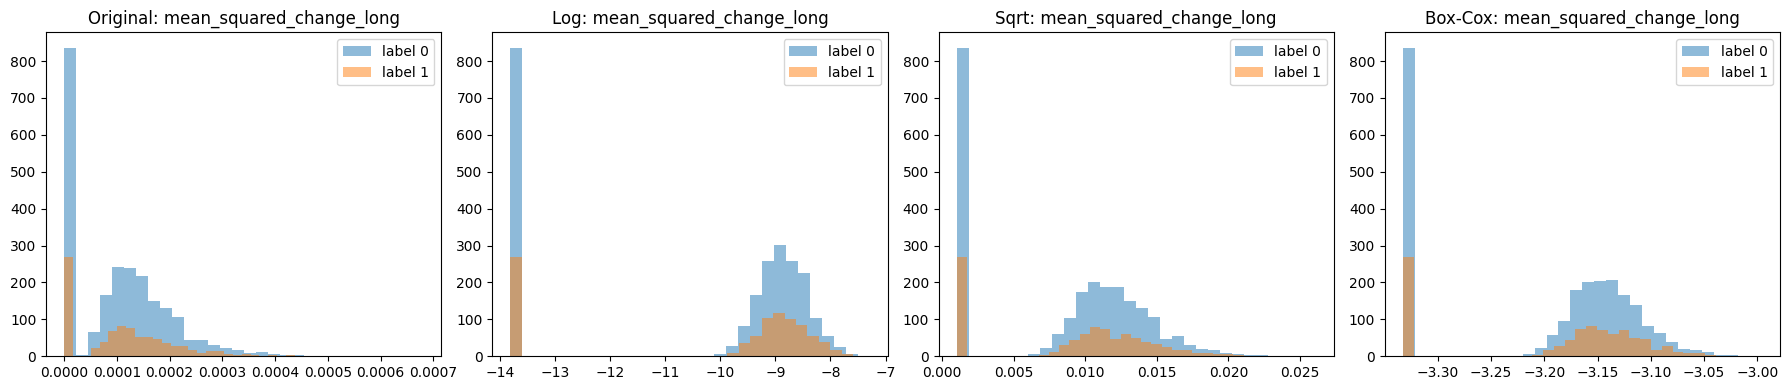

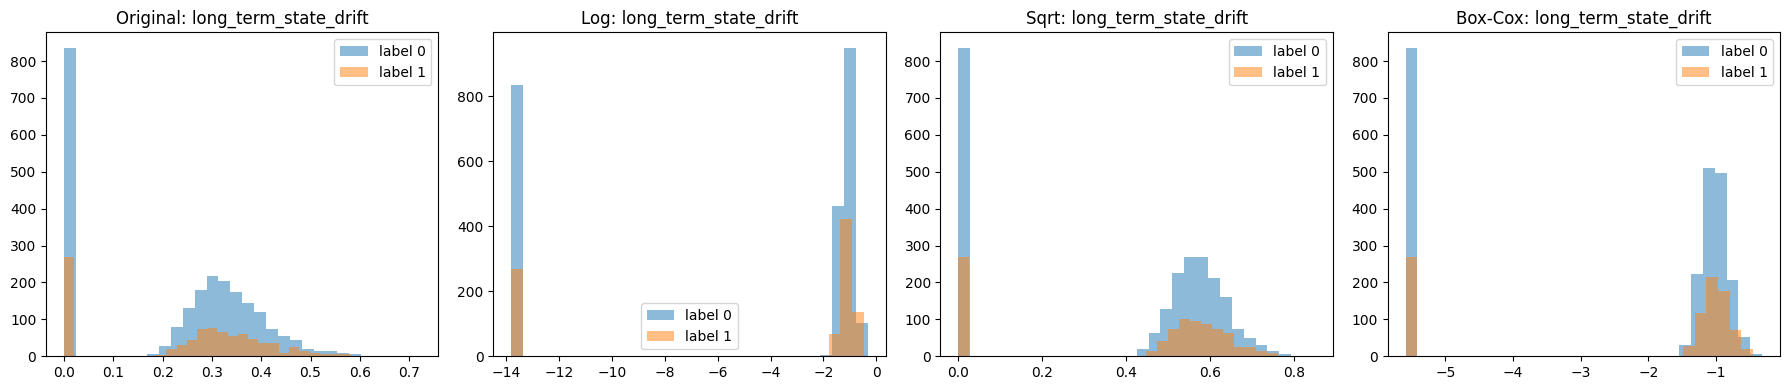

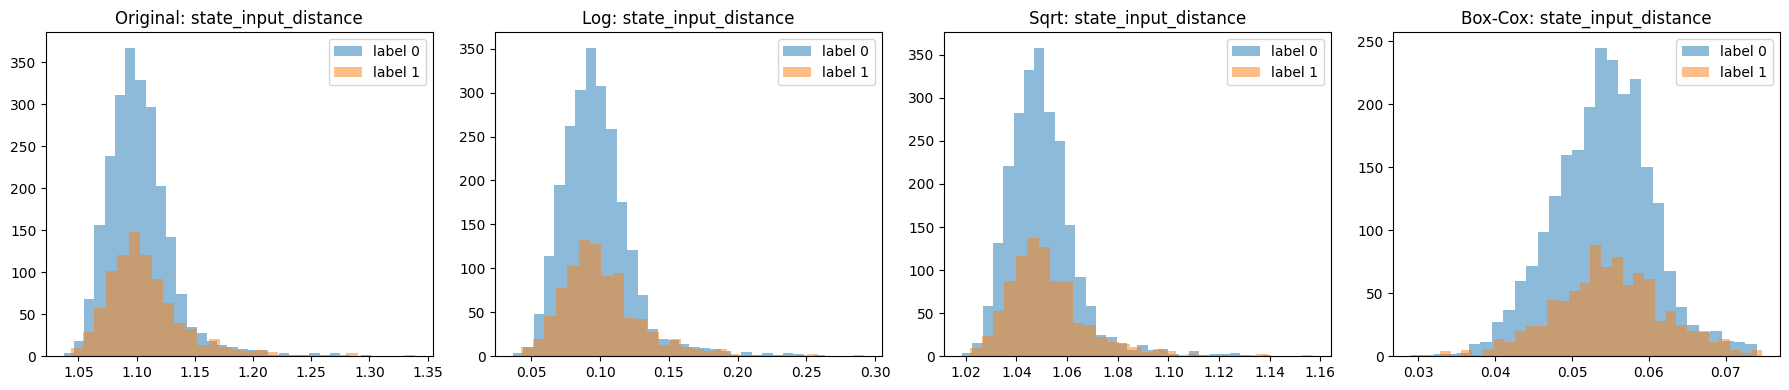

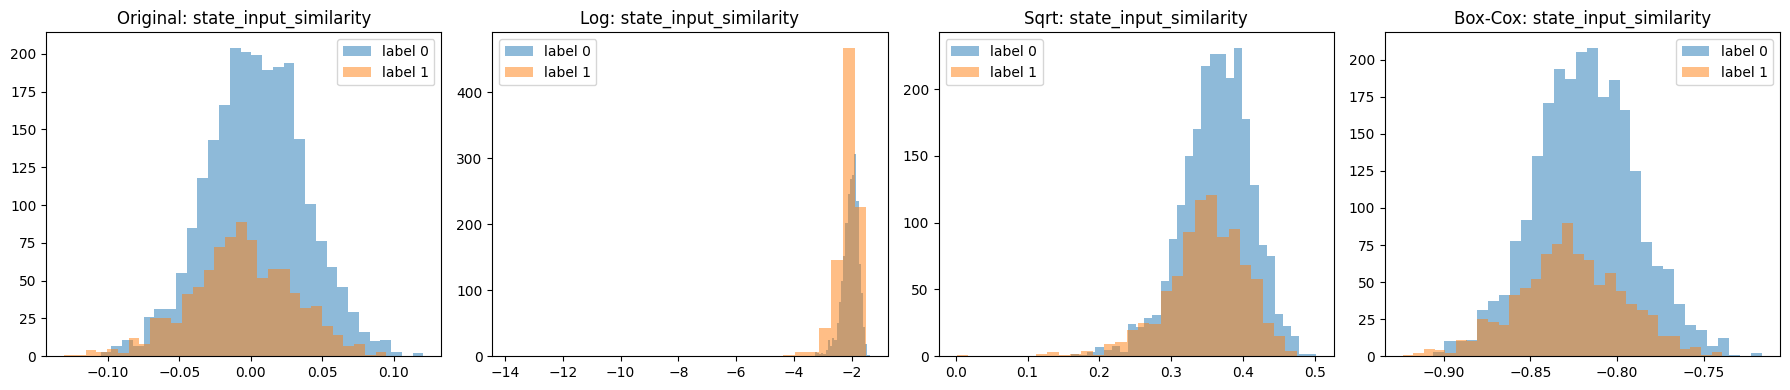

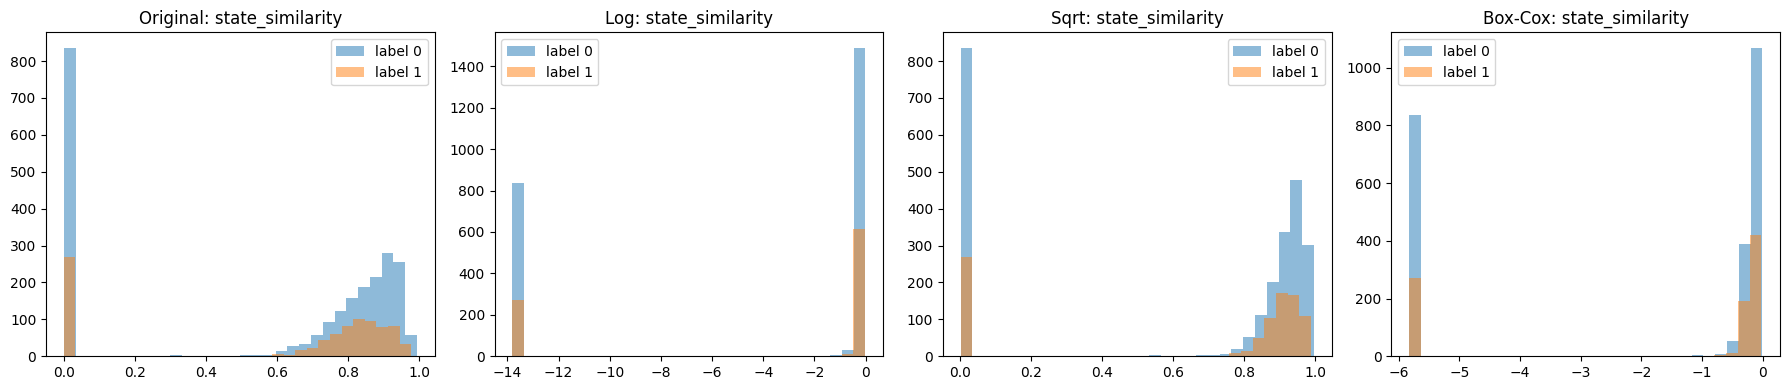

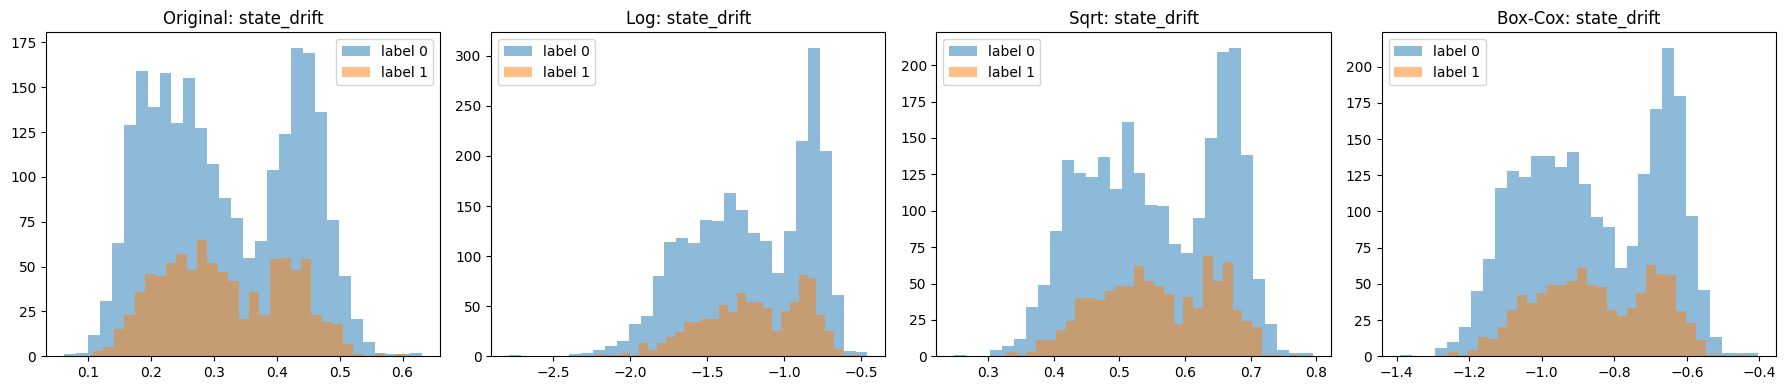

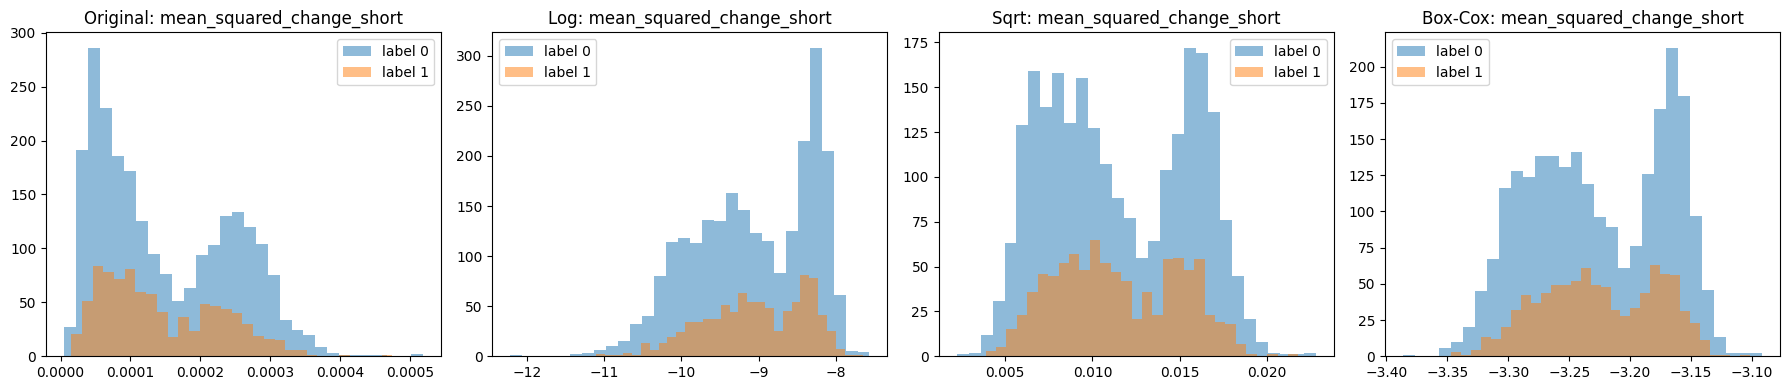

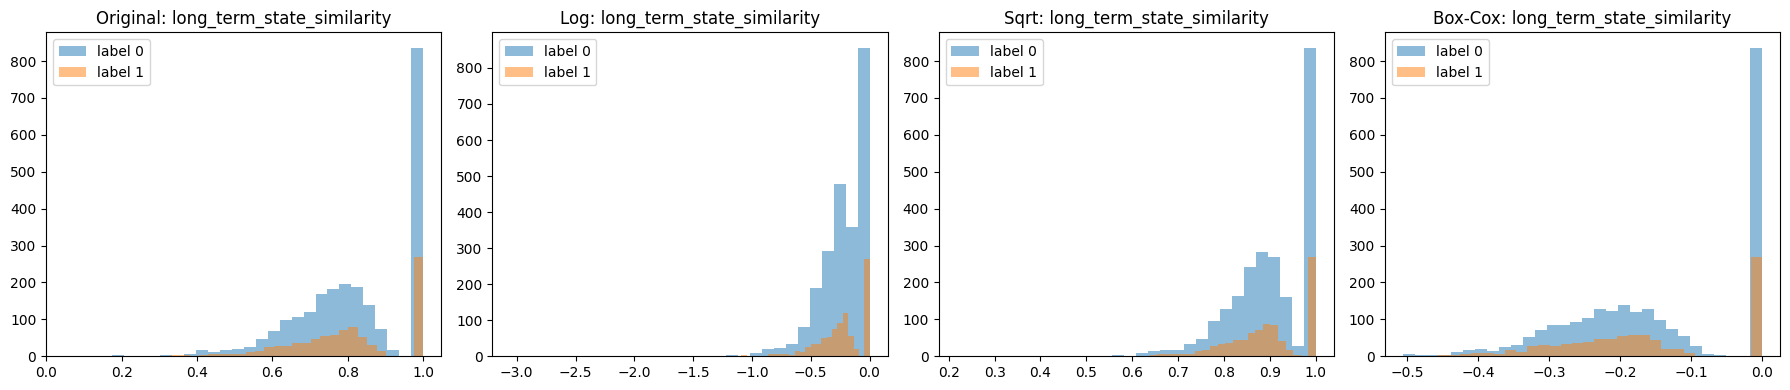

In [256]:
for feature in feature_names:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    for lbl in df_trans["label"].unique():
        subset = df_trans[df_trans["label"] == lbl][feature+"_orig"]
        axes[0].hist(subset, bins=30, alpha=0.5, label=f"label {lbl}")
        subset_log = df_trans[df_trans["label"] == lbl][f"{feature}_log"]
        axes[1].hist(subset_log, bins=30, alpha=0.5, label=f"label {lbl}")
        subset_sqrt = df_trans[df_trans["label"] == lbl][f"{feature}_sqrt"]
        axes[2].hist(subset_sqrt, bins=30, alpha=0.5, label=f"label {lbl}")
        subset_boxcox = df_trans[df_trans["label"] == lbl][f"{feature}_boxcox"]
        axes[3].hist(subset_boxcox, bins=30, alpha=0.5, label=f"label {lbl}")

    axes[0].set_title(f"Original: {feature}")
    axes[1].set_title(f"Log: {feature}")
    axes[2].set_title(f"Sqrt: {feature}")
    axes[3].set_title(f"Box-Cox: {feature}")

    for ax in axes:
        ax.legend()

    plt.tight_layout()
    plt.show()

In [257]:
df_trans = pd.DataFrame(all_features)
df_trans["label"] = df["label"]

In [258]:
df_trans

,mean_squared_change_long_orig,mean_squared_change_long_log,mean_squared_change_long_sqrt,mean_squared_change_long_boxcox,long_term_state_drift_orig,long_term_state_drift_log,long_term_state_drift_sqrt,long_term_state_drift_boxcox,state_input_distance_orig,state_input_distance_log,...,state_drift_boxcox,mean_squared_change_short_orig,mean_squared_change_short_log,mean_squared_change_short_sqrt,mean_squared_change_short_boxcox,long_term_state_similarity_orig,long_term_state_similarity_log,long_term_state_similarity_sqrt,long_term_state_similarity_boxcox,label
0,0.000000,-13.815511,0.001000,-3.332817,0.000000,-13.815511,0.001000,-5.589465,1.060708,0.058937,...,-0.677197,0.000235,-8.357607,0.015317,-3.173172,1.000000,0.000000e+00,1.000000,0.000000e+00,0
1,0.000106,-9.140976,0.010353,-3.161692,0.285567,-1.253276,0.534385,-1.136285,1.122548,0.115601,...,-0.894268,0.000106,-9.150349,0.010304,-3.237943,0.808949,-2.120188e-01,0.899416,-1.732962e-01,1
2,0.000186,-8.584956,0.013671,-3.120927,0.377847,-0.973263,0.614694,-0.901685,1.142455,0.133179,...,-0.973178,0.000076,-9.489843,0.008696,-3.261488,0.684473,-3.791064e-01,0.827329,-2.670334e-01,1
3,0.000000,-13.815511,0.001000,-3.332817,0.000000,-13.815511,0.001000,-5.589465,1.077727,0.074854,...,-0.731892,0.000195,-8.541038,0.013975,-3.189492,1.000000,1.192093e-07,1.000000,1.192093e-07,1
4,0.000000,-13.815511,0.001000,-3.332817,0.000000,-13.815511,0.001000,-5.589465,1.103862,0.098815,...,-0.640652,0.000264,-8.240206,0.016243,-3.162268,1.000000,0.000000e+00,1.000000,0.000000e+00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3250,0.000080,-9.420382,0.009003,-3.179787,0.247956,-1.394499,0.497953,-1.250700,1.140951,0.131862,...,-0.960449,0.000080,-9.432796,0.008947,-3.257690,0.888274,-1.184747e-01,0.942483,-1.056590e-01,0
3251,0.000168,-8.686794,0.012992,-3.128902,0.358986,-1.024470,0.599155,-0.945372,1.126272,0.118913,...,-0.805413,0.000150,-8.803843,0.012254,-3.211430,0.752965,-2.837366e-01,0.867736,-2.173327e-01,0
3252,0.000188,-8.573173,0.013752,-3.119989,0.380092,-0.967340,0.616517,-0.896609,1.122902,0.115916,...,-1.106623,0.000039,-10.151738,0.006246,-3.301306,0.716930,-3.327776e-01,0.846717,-2.440547e-01,0
3253,0.000194,-8.540474,0.013978,-3.117368,0.386390,-0.950905,0.621604,-0.882499,1.129853,0.122087,...,-1.098706,0.000041,-10.108768,0.006381,-3.298944,0.707347,-3.462340e-01,0.841039,-2.509466e-01,0


In [259]:
corr_with_label = df_trans.corr(method="spearman")["label"].drop("label")

In [260]:
best_features = []

for f in feature_names:
    candidates = {
        "orig": corr_with_label.get(f"{f}_orig", 0),
        "log": corr_with_label.get(f"{f}_log", 0),
        "sqrt": corr_with_label.get(f"{f}_sqrt", 0),
        "boxcox": corr_with_label.get(f"{f}_boxcox", 0),
    }

    best_variant = max(candidates, key=lambda k: abs(candidates[k]))
    best_features.append(f"{f}_{best_variant}")

In [261]:
best_features

['mean_squared_change_long_orig',
 'long_term_state_drift_orig',
 'state_input_distance_orig',
 'state_input_similarity_orig',
 'state_similarity_orig',
 'state_drift_orig',
 'mean_squared_change_short_orig',
 'long_term_state_similarity_orig']

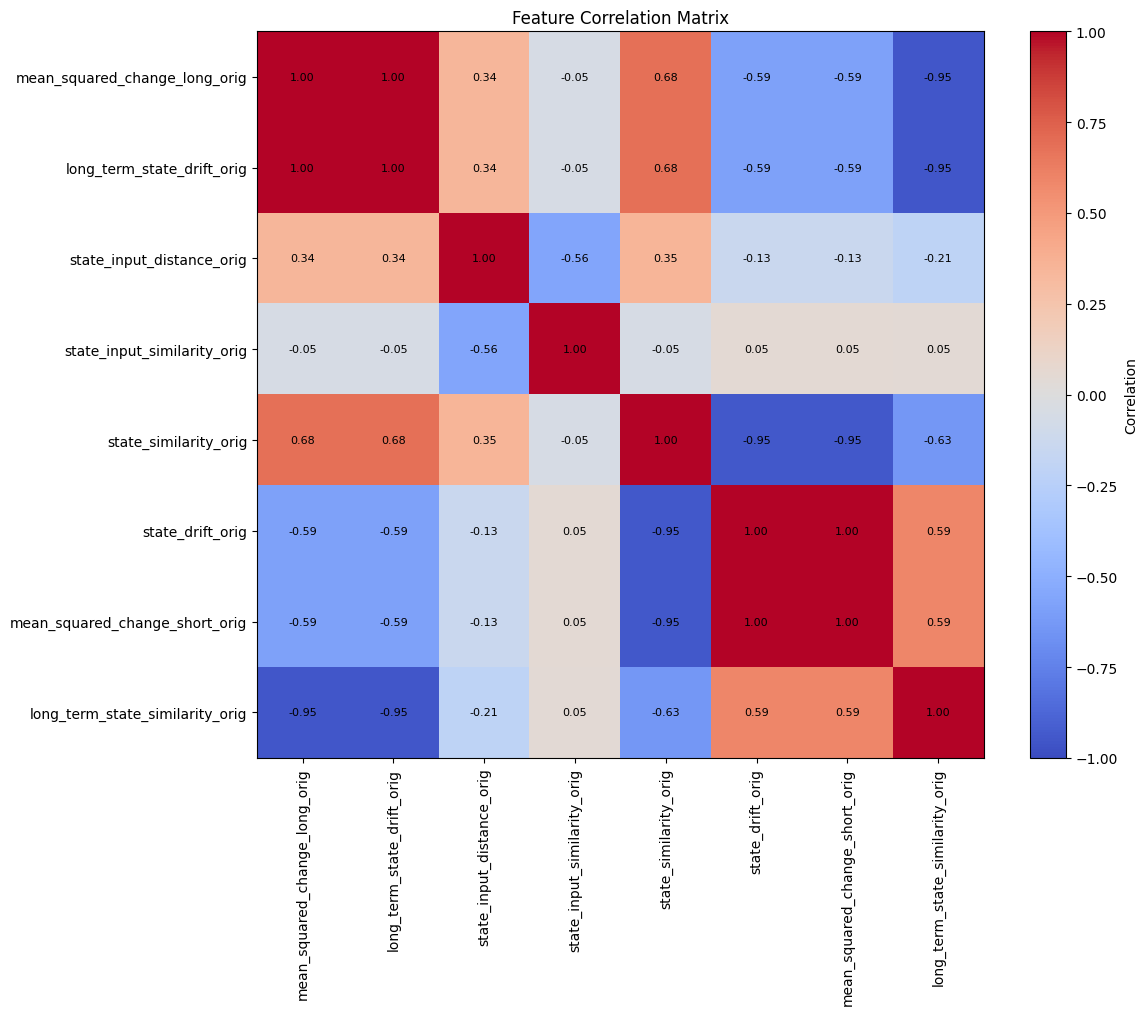

In [262]:
feature_df = df_trans[best_features]
corr_matrix = feature_df.corr(numeric_only=True,method="spearman")

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, interpolation="nearest", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(
    np.arange(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)
plt.yticks(
    np.arange(len(corr_matrix.columns)),
    corr_matrix.columns
)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=8
        )

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [263]:
from sklearn.ensemble import RandomForestClassifier

X = df_trans[best_features]
y = df_trans["label"]

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X, y)

importances = model.feature_importances_

feature_importance = sorted(
    zip(X.columns, importances),
    key=lambda x: x[1],
    reverse=True
)

for f, imp in feature_importance:
    print(f"{f}: {imp:.4f}")

state_input_similarity_orig: 0.1669
state_input_distance_orig: 0.1642
state_drift_orig: 0.1492
mean_squared_change_short_orig: 0.1370
state_similarity_orig: 0.1042
long_term_state_similarity_orig: 0.1001
long_term_state_drift_orig: 0.0897
mean_squared_change_long_orig: 0.0886


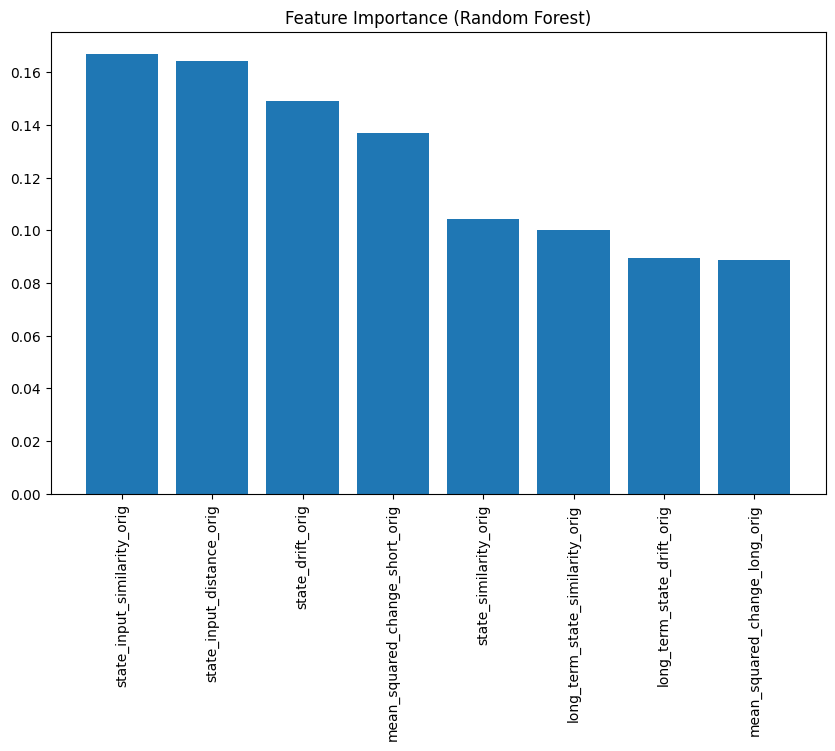

In [264]:
names = [f for f, _ in feature_importance]
values = [imp for _, imp in feature_importance]

plt.figure(figsize=(10, 6))
plt.bar(names, values)
plt.xticks(rotation=90)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [265]:
result = permutation_importance(
    model, X, y,
    n_repeats=10,
    random_state=42
)

In [266]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": result.importances_mean,
    "std": result.importances_std
})

importances = importances.sort_values("importance", ascending=False)
print(importances)

                           feature  importance       std
3      state_input_similarity_orig    0.135822  0.004111
2        state_input_distance_orig    0.109862  0.003076
7  long_term_state_similarity_orig    0.060492  0.003015
5                 state_drift_orig    0.055822  0.002400
4            state_similarity_orig    0.053210  0.002414
6   mean_squared_change_short_orig    0.041382  0.001987
0    mean_squared_change_long_orig    0.030661  0.002465
1       long_term_state_drift_orig    0.020829  0.001642


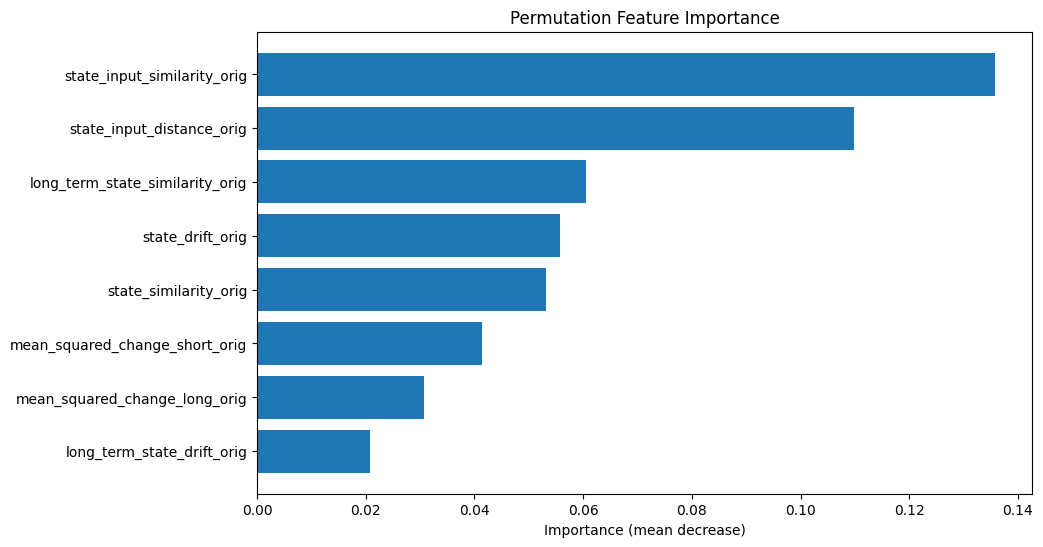

In [267]:
plt.figure(figsize=(10, 6))
plt.barh(importances["feature"], importances["importance"])
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance")
plt.xlabel("Importance (mean decrease)")
plt.show()

In [268]:
feature_names=feature_df.columns.tolist()

In [269]:
feature_names

['mean_squared_change_long_orig',
 'long_term_state_drift_orig',
 'state_input_distance_orig',
 'state_input_similarity_orig',
 'state_similarity_orig',
 'state_drift_orig',
 'mean_squared_change_short_orig',
 'long_term_state_similarity_orig']

In [274]:
selected_features = [
    'state_input_similarity',
    'state_drift',
    'state_input_distance',
    'long_term_state_similarity',
    'mean_squared_change_short'
]

In [275]:
df_final=df_all[vector_list+ selected_features  + ["conv_id","turn_id"]+["y"]]

In [276]:
df_final

,0,1,2,3,4,5,6,7,8,9,...,conv_id,turn_id,state_input_similarity,state_drift,state_input_distance,long_term_state_similarity,mean_squared_change_short,conv_id,turn_id,y
0,-0.004938,0.010028,-0.009252,0.005573,0.004999,0.004853,-0.015082,-0.023915,0.014907,0.005539,...,0.0,0.0,0.064875,0.424472,1.060708,1.000000,0.000235,0.0,0.0,0
1,-0.005842,0.028222,-0.015452,-0.032046,0.014550,0.003275,-0.012755,-0.021501,0.033707,0.023255,...,0.0,1.0,-0.028589,0.285567,1.122548,0.808949,0.000106,0.0,1.0,1
2,0.002231,0.032334,-0.024924,-0.034721,0.016211,-0.005692,-0.002074,-0.026771,0.027421,0.023131,...,0.0,2.0,-0.047110,0.240984,1.142455,0.684473,0.000076,0.0,2.0,1
3,-0.015485,-0.014725,0.005911,0.019545,0.010477,-0.001654,-0.009771,-0.001021,0.006958,-0.011655,...,1.0,0.0,-0.014866,0.387274,1.077727,1.000000,0.000195,1.0,0.0,1
4,0.021614,0.011441,-0.005190,-0.016628,-0.003228,-0.013043,-0.000234,0.005934,0.004089,0.014867,...,2.0,0.0,-0.017649,0.450135,1.103862,1.000000,0.000264,2.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3250,0.028141,0.024459,-0.010783,-0.028157,-0.004694,-0.009067,0.001867,0.006221,0.029151,0.002131,...,1105.0,1.0,-0.024465,0.247956,1.140951,0.888274,0.000080,1105.0,1.0,0
3251,0.021432,0.030566,-0.024104,-0.016266,0.008490,0.000462,0.018579,-0.030009,0.000419,0.006191,...,1105.0,2.0,-0.023789,0.339587,1.126272,0.752965,0.000150,1105.0,2.0,0
3252,0.016158,0.024588,-0.012411,-0.021500,0.015316,0.004914,0.020081,-0.034528,0.009645,0.010855,...,1105.0,3.0,-0.030448,0.173085,1.122902,0.716930,0.000039,1105.0,3.0,0
3253,0.017627,0.023378,-0.015379,-0.022957,0.023361,0.008762,0.024364,-0.027640,-0.001722,-0.000399,...,1105.0,4.0,-0.046727,0.176844,1.129853,0.707347,0.000041,1105.0,4.0,0


In [277]:
df_final.to_csv("./../data/ssm_final_features_extended.csv", index=False)